<a href="https://colab.research.google.com/github/pedroabreu2359/Atividade-de-Machine-Learning-Regressao/blob/main/NotebookRegressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Real State Valuation Dataset** — Dataset de Taiwan sobre preços de imóveis, com colunas como distância até estação de metrô, número de lojas de conveniência próximas, latitude, longitude e idade do imóvel — todas numéricas, target também numérico (preço por área).
https://www.kaggle.com/datasets/quantbruce/real-estate-price-prediction

*   **Calculate Concrete Strength** — Dataset sobre resistência de concreto, com colunas como quantidade de cimento, água, agregados, idade da mistura — tudo numérico, prevendo a resistência à compressão (target numérico).
https://www.kaggle.com/datasets/prathamtripathi/regression-with-neural-networking



In [48]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [49]:
# Carregue seu dataset aqui
# Coloque o caminho do arquivo CSV que você baixou do Kaggle entre as aspas abaixo
df = pd.read_csv("/content/Real estate.csv")  # TODO: coloque o path do seu arquivo CSV aqui

# Separe suas features (X) e seu target (y)
# X = todas as colunas que serão usadas para prever (menos a coluna target)
# y = a coluna que você quer prever (deve ser numérica, já que é regressão)

X = df.drop(columns=['No', 'Y house price of unit area'])
y = df['Y house price of unit area']

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Faixa da variável target: {y.min():.2f} - {y.max():.2f}")
print(f"Valor médio do target: {y.mean():.2f}")

Dataset carregado com sucesso!
Formato do dataset: (414, 6)
Número de amostras: 414
Número de features: 6
Faixa da variável target: 7.60 - 117.50
Valor médio do target: 37.98


In [50]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS ===")
print(X.head())


=== VISÃO GERAL DO DATASET ===
Formato do dataset: (414, 6)
Formato do target: (414,)

=== PRIMEIRAS 5 LINHAS ===
   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  
0                               10     24.98298     121.54024  
1                                9     24.98034     121.53951  
2                                5     24.98746     121.54391  
3                                5     24.98746     121.54391  
4                                5     24.97937     121.54245  


In [51]:
print("\n=== RESUMO ESTATÍSTICO ===")
X.describe()


=== RESUMO ESTATÍSTICO ===


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270


In [52]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


In [53]:
print(f"\nValores ausentes nas features: ")
X.isnull().sum().sum()
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")


Valores ausentes nas features: 
Valores ausentes no target: 0


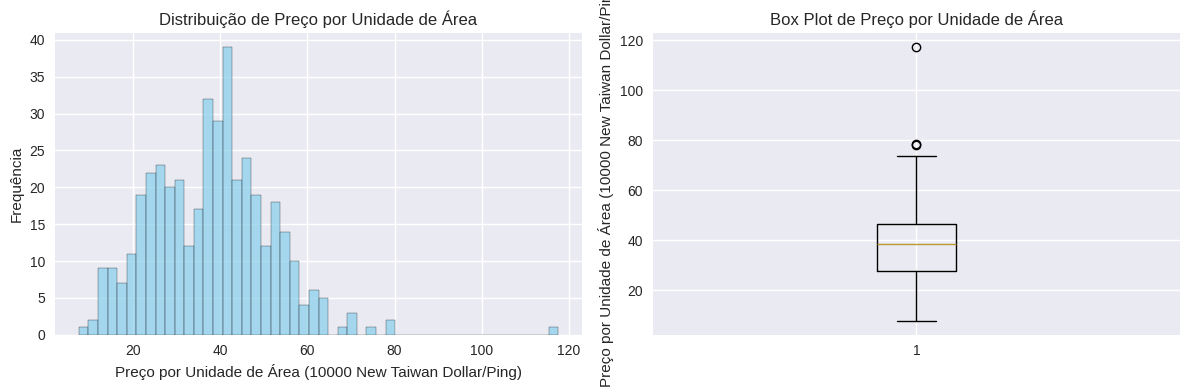

Estatísticas da variável target:
Média: 37.98 (10000 New Taiwan Dollar/Ping)
Mediana: 38.45 (10000 New Taiwan Dollar/Ping)
Desvio padrão: 13.61 (10000 New Taiwan Dollar/Ping)


In [54]:
# Definindo o nome do que você está prevendo e a unidade de medida
nome_target = "Preço por Unidade de Área"
unidade_target = "(10000 New Taiwan Dollar/Ping)"

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribuição de {nome_target}')
plt.xlabel(f'{nome_target} {unidade_target}')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True)
plt.title(f'Box Plot de {nome_target}')
plt.ylabel(f'{nome_target} {unidade_target}')

plt.tight_layout()
plt.show()

print(f"Estatísticas da variável target:")
print(f"Média: {y.mean():.2f} {unidade_target}")
print(f"Mediana: {np.median(y):.2f} {unidade_target}")
print(f"Desvio padrão: {y.std():.2f} {unidade_target}")

=== FEATURES (X) ===
Formato das features: (414, 6)
Nomes das features: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
Tipos das features: [dtype('float64') dtype('int64')]

=== TARGET (y) ===
Formato do target: (414,)
Tipo do target: <class 'pandas.core.series.Series'>
Target é o que queremos prever: Preços das casas


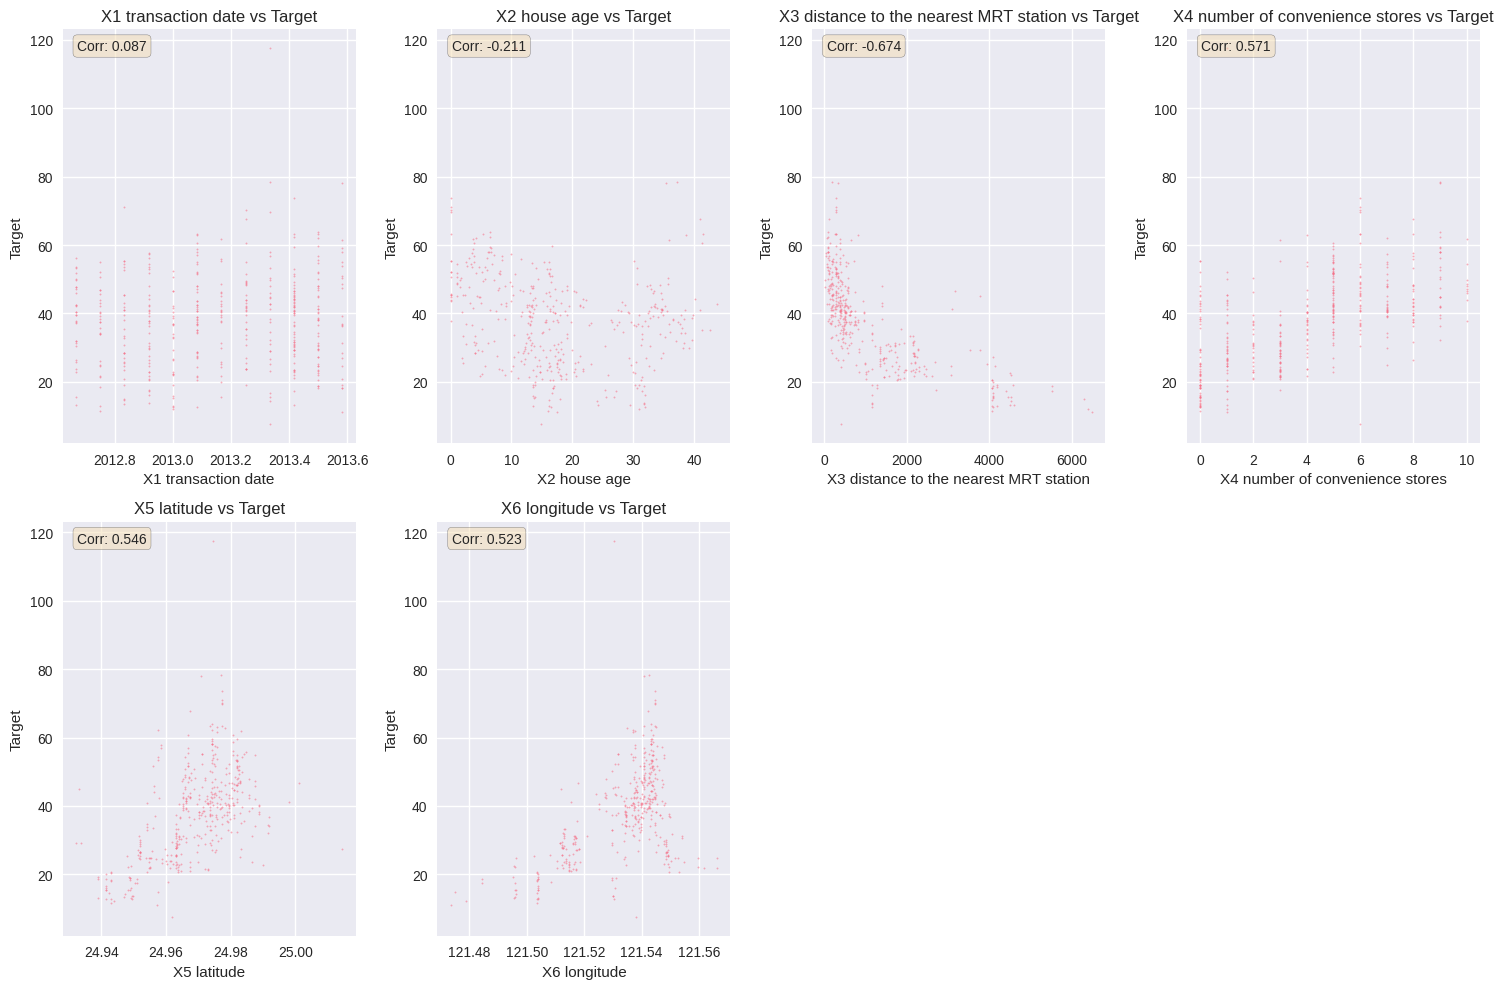

In [55]:
# Já separamos nossas variáveis, mas vamos confirmar e visualizar a relação
print("=== FEATURES (X) ===")
print(f"Formato das features: {X.shape}")
print(f"Nomes das features: {list(X.columns)}")
print(f"Tipos das features: {X.dtypes.unique()}")

print("\n=== TARGET (y) ===")
print(f"Formato do target: {y.shape}")
print(f"Tipo do target: {type(y)}")
print(f"Target é o que queremos prever: Preços das casas")

# Vamos ver a correlação entre features e target
plt.figure(figsize=(15, 10))
n_features = len(X.columns)
n_cols = 4
n_rows = -(-n_features // n_cols)  # arredonda pra cima

for i, column in enumerate(X.columns):
    plt.subplot(n_rows, n_cols, i+1)
    plt.scatter(X[column], y, alpha=0.5, s=1)
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.title(f'{column} vs Target')

    correlation = X[column].corr(pd.Series(y))
    plt.text(0.05, 0.95, f'Corr: {correlation:.3f}',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


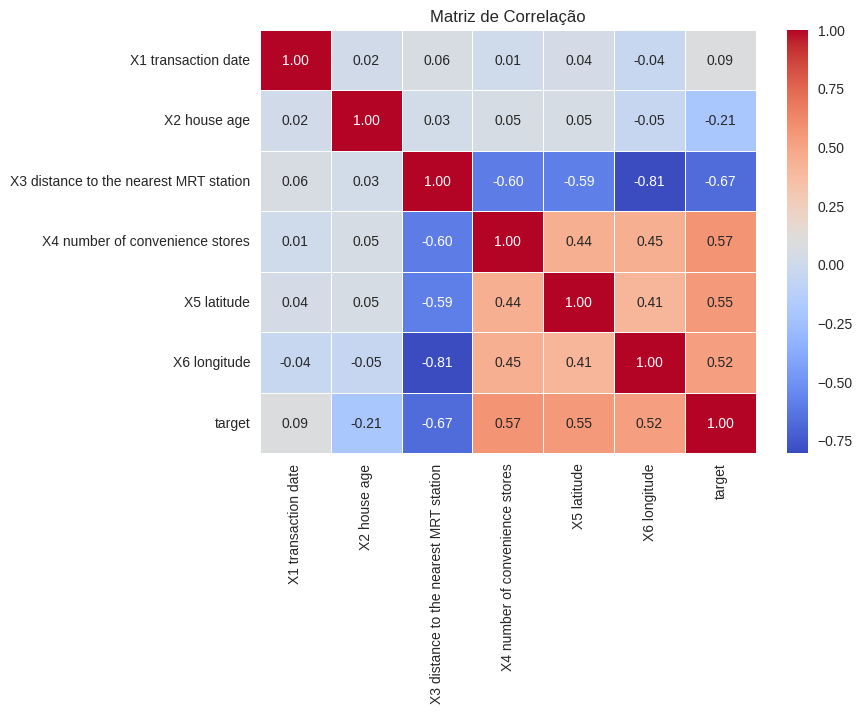

In [56]:
# unimos X e y em um único DataFrame para o cálculo
# Usamos pd.concat para colocar a coluna do target ao lado das outras features
df_para_corr = pd.concat([X, pd.Series(y, name='target')], axis=1)

# matriz de correlação usando o Pandas
matriz_corr = df_para_corr.corr()

# visualizamos com o Seaborn (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [57]:
# Dividir os dados em conjuntos de treino e teste
# test_size=0.2 significa 20% para teste, 80% para treino
# random_state=42 garante resultados reproduzíveis (mesma divisão sempre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nFormato das features de treino: {X_train.shape}")
print(f"Formato do target de treino: {y_train.shape}")
print(f"Formato das features de teste: {X_test.shape}")
print(f"Formato do target de teste: {y_test.shape}")

print(f"\nEstatísticas do target do conjunto de treino:")
print(f"Média: ${y_train.mean():.2f}, Desvio: ${y_train.std():.2f}")
print(f"Estatísticas do target do conjunto de teste:")
print(f"Média: ${y_test.mean():.2f}, Desvio: ${y_test.std():.2f}")
print("✓ Ambos conjuntos têm distribuições similares - boa divisão!")


=== RESULTADOS DA DIVISÃO DOS DADOS ===
Tamanho do dataset original: 414 amostras
Tamanho do conjunto de treino: 331 amostras (80.0%)
Tamanho do conjunto de teste: 83 amostras (20.0%)

Formato das features de treino: (331, 6)
Formato do target de treino: (331,)
Formato das features de teste: (83, 6)
Formato do target de teste: (83,)

Estatísticas do target do conjunto de treino:
Média: $38.39, Desvio: $13.74
Estatísticas do target do conjunto de teste:
Média: $36.34, Desvio: $13.03
✓ Ambos conjuntos têm distribuições similares - boa divisão!


In [58]:
# Antes do escalonamento - vamos ver as distribuições originais das features
print("=== ANTES DO ESCALONAMENTO ===")
print("Estatísticas das features do conjunto de treino:")
print(X_train.describe())

# Criar uma instância do StandardScaler
scaler = StandardScaler()

# IMPORTANTE: Ajustar o scaler APENAS nos dados de treino
# Isso previne vazamento de dados do conjunto de teste
scaler.fit(X_train)

# Transformar ambos os conjuntos (treino e teste) usando o scaler ajustado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manipulação mais fácil
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n=== APÓS O ESCALONAMENTO ===")
print("Estatísticas das features escalonadas do conjunto de treino:")
print(X_train_scaled.describe())

print(f"\n✓ Todas as features agora têm média ≈ 0 e desvio ≈ 1")
print(f"✓ Scaler foi ajustado apenas nos dados de treino")
print(f"✓ Mesma transformação aplicada em ambos os conjuntos (treino e teste)")


=== ANTES DO ESCALONAMENTO ===
Estatísticas das features do conjunto de treino:
       X1 transaction date  X2 house age  \
count           331.000000    331.000000   
mean           2013.166683     17.288822   
std               0.281570     11.327281   
min            2012.667000      0.000000   
25%            2012.917000      8.450000   
50%            2013.167000     15.900000   
75%            2013.417000     27.200000   
max            2013.583000     43.800000   

       X3 distance to the nearest MRT station  \
count                              331.000000   
mean                              1059.603962   
std                               1217.929569   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1442.932500   
max                               6306.153000   

       X4 number of convenience stores  X5 latitude  X6 longitude  
count        

In [59]:
# Criar um modelo de Regressão Linear
model = LinearRegression()

print("=== TREINAMENTO DO MODELO ===")
print(f"Modelo criado: {model}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

# Treinar o modelo com nossos dados de treino escalonados
# É aqui que o modelo aprende a relação entre features e target
model.fit(X_train_scaled, y_train)

print("✓ Treinamento do modelo concluído!")

# Vamos examinar o que o modelo aprendeu
print(f"\n=== PARÂMETROS DO MODELO ===")
print(f"Intercepto (β₀): {model.intercept_:.4f}")
print(f"Coeficientes (β₁...βₙ):")

# Exibir coeficientes para cada feature
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\n=== INTERPRETAÇÃO ===")
print("A equação do modelo é:")
equation = f"{nome_target} = {model.intercept_:.4f}"
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign}{coef:.4f}*{feature}"
print(equation)

=== TREINAMENTO DO MODELO ===
Modelo criado: LinearRegression()
Treinando com 331 amostras e 6 features
✓ Treinamento do modelo concluído!

=== PARÂMETROS DO MODELO ===
Intercepto (β₀): 38.3915
Coeficientes (β₁...βₙ):
  X1 transaction date: 1.5296
  X2 house age: -3.0627
  X3 distance to the nearest MRT station: -5.7869
  X4 number of convenience stores: 3.2189
  X5 latitude: 2.8551
  X6 longitude: -0.4410

=== INTERPRETAÇÃO ===
A equação do modelo é:
Preço por Unidade de Área = 38.3915 +1.5296*X1 transaction date -3.0627*X2 house age -5.7869*X3 distance to the nearest MRT station +3.2189*X4 number of convenience stores +2.8551*X5 latitude -0.4410*X6 longitude


In [60]:
# Fazer predições nos conjuntos de treino e teste
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("=== PREDIÇÕES REALIZADAS ===")
print(f"Formato das predições de treino: {y_train_pred.shape}")
print(f"Formato das predições de teste: {y_test_pred.shape}")

# Vamos ver alguns exemplos de predições vs valores reais
print(f"\n=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===")
comparison_df = pd.DataFrame({
    'Real': y_test[:10],
    'Predito': y_test_pred[:10],
    'Diferença': y_test[:10] - y_test_pred[:10]
})
print(comparison_df)

print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Conjunto de treino:")
print(f"  Média real: ${y_train.mean():.2f}")
print(f"  Média predita: ${y_train_pred.mean():.2f}")
print(f"Conjunto de teste:")
print(f"  Média real: ${y_test.mean():.2f}")
print(f"  Média predita: ${y_test_pred.mean():.2f}")


=== PREDIÇÕES REALIZADAS ===
Formato das predições de treino: (331,)
Formato das predições de teste: (83,)

=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===
     Real    Predito  Diferença
358  45.1  47.886254  -2.786254
350  42.3  41.164046   1.135954
373  52.2  44.273014   7.926986
399  37.3  40.197615  -2.897615
369  22.8  27.513265  -4.713265
72   36.3  45.109531  -8.809531
262  53.0  44.632933   8.367067
140  51.4  46.363462   5.036538
93   16.1  23.620631  -7.520631
70   59.0  54.334449   4.665551

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Conjunto de treino:
  Média real: $38.39
  Média predita: $38.39
Conjunto de teste:
  Média real: $36.34
  Média predita: $36.22


In [61]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calcular e exibir métricas de avaliação do modelo"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"=== AVALIAÇÃO DO CONJUNTO {dataset_name.upper()} ===")
    print(f"Score R²: {r2:.4f} ({r2*100:.2f}% da variância explicada)")
    print(f"Erro Quadrático Médio: {mse:.4f}")
    print(f"Raiz do Erro Quadrático Médio: {rmse:.4f} {unidade_target}")
    print(f"Erro Absoluto Médio: {mae:.4f} {unidade_target}")

    return r2, mse, rmse, mae

train_r2, train_mse, train_rmse, train_mae = evaluate_model(y_train, y_train_pred, "treino")
print()
test_r2, test_mse, test_rmse, test_mae = evaluate_model(y_test, y_test_pred, "teste")

print(f"\n=== RESUMO DA PERFORMANCE DO MODELO ===")
print(f"R² Treino: {train_r2:.4f} | R² Teste: {test_r2:.4f}")
print(f"RMSE Treino: {train_rmse:.4f} | RMSE Teste: {test_rmse:.4f}")

if train_r2 - test_r2 > 0.1:
    print("⚠️  Possível overfitting detectado (R² treino >> R² teste)")
elif abs(train_r2 - test_r2) < 0.05:
    print("✓ Boa generalização (performance similar em treino/teste)")
else:
    print("✓ Modelo parece generalizar bem")

=== AVALIAÇÃO DO CONJUNTO TREINO ===
Score R²: 0.5581 (55.81% da variância explicada)
Erro Quadrático Médio: 83.1135
Raiz do Erro Quadrático Médio: 9.1167 (10000 New Taiwan Dollar/Ping)
Erro Absoluto Médio: 6.3397 (10000 New Taiwan Dollar/Ping)

=== AVALIAÇÃO DO CONJUNTO TESTE ===
Score R²: 0.6811 (68.11% da variância explicada)
Erro Quadrático Médio: 53.5056
Raiz do Erro Quadrático Médio: 7.3148 (10000 New Taiwan Dollar/Ping)
Erro Absoluto Médio: 5.3054 (10000 New Taiwan Dollar/Ping)

=== RESUMO DA PERFORMANCE DO MODELO ===
R² Treino: 0.5581 | R² Teste: 0.6811
RMSE Treino: 9.1167 | RMSE Teste: 7.3148
✓ Modelo parece generalizar bem


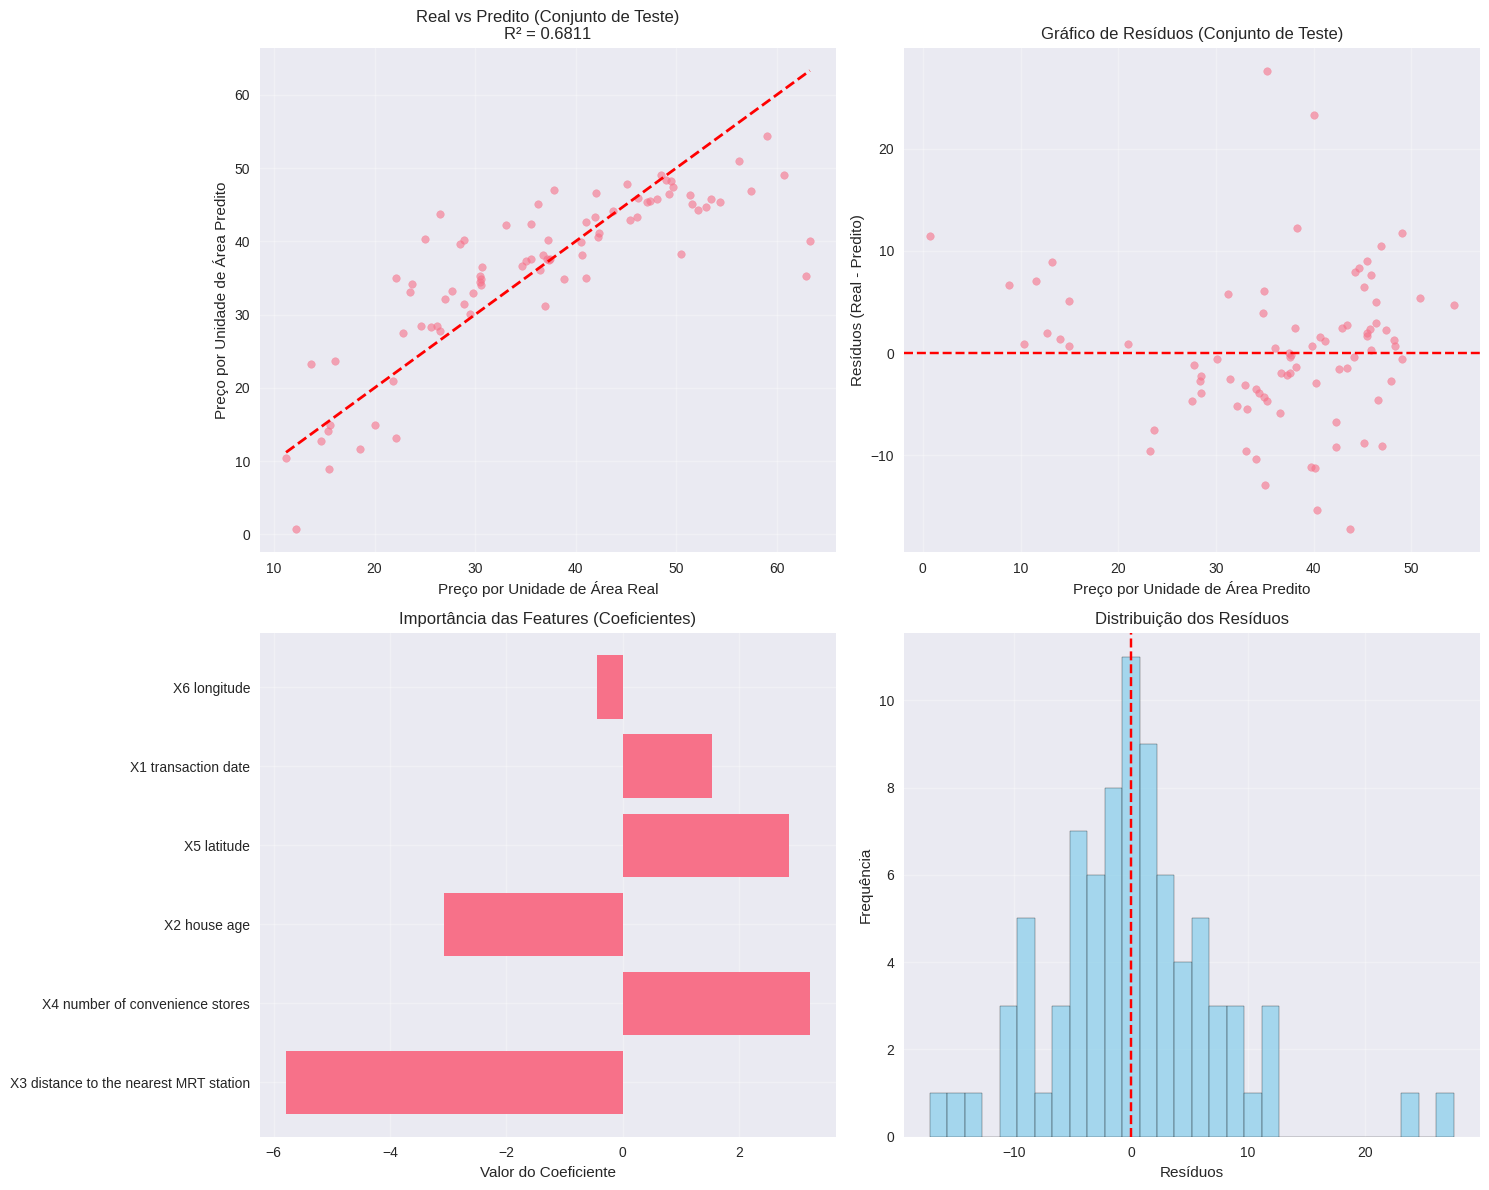

=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===
1. Real vs Predito: Pontos próximos à linha vermelha indicam boas predições
2. Gráfico de Resíduos: Pontos aleatoriamente espalhados ao redor do zero indicam bom ajuste do modelo
3. Importância das Features: Mostra quais features têm a influência mais forte
4. Distribuição dos Resíduos: Deve ser aproximadamente normal (forma de sino) ao redor do zero


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Real vs Predito (Conjunto de Teste)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, s=30)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel(f'{nome_target} Real')
axes[0, 0].set_ylabel(f'{nome_target} Predito')
axes[0, 0].set_title(f'Real vs Predito (Conjunto de Teste)\nR² = {test_r2:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de Resíduos (Conjunto de Teste)
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel(f'{nome_target} Predito')
axes[0, 1].set_ylabel('Resíduos (Real - Predito)')
axes[0, 1].set_title('Gráfico de Resíduos (Conjunto de Teste)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Importância das Features (Coeficientes)
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})
feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=False)

axes[1, 0].barh(feature_importance['Feature'], feature_importance['Coefficient'])
axes[1, 0].set_xlabel('Valor do Coeficiente')
axes[1, 0].set_title('Importância das Features (Coeficientes)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribuição dos Resíduos
axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Resíduos')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Resíduos')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===")
print("1. Real vs Predito: Pontos próximos à linha vermelha indicam boas predições")
print("2. Gráfico de Resíduos: Pontos aleatoriamente espalhados ao redor do zero indicam bom ajuste do modelo")
print("3. Importância das Features: Mostra quais features têm a influência mais forte")
print("4. Distribuição dos Resíduos: Deve ser aproximadamente normal (forma de sino) ao redor do zero")

In [63]:
# Insights adicionais: Análise das features
print("=== ANÁLISE DETALHADA DAS FEATURES ===")
print("\nFeatures mais importantes (por valor absoluto do coeficiente):")
for i, row in feature_importance.head(3).iterrows():
    coef_value = row['Coefficient']
    feature_name = row['Feature']
    direction = "aumenta" if coef_value > 0 else "diminui"
    print(f"• {feature_name}: {abs(coef_value):.4f} - {nome_target} {direction} quando esta feature aumenta")

print(f"\nResumo da Performance do Modelo:")
print(f"• O modelo explica {test_r2*100:.1f}% da variância em {nome_target}")
print(f"• Erro médio de predição: {test_mae:.2f} {unidade_target}")
print(f"• Modelo pode prever {nome_target} dentro de ±{test_rmse:.2f} {unidade_target} em média")

print(f"\n=== EXEMPLO DE PREDIÇÃO ===")
sample_features = X_test_scaled.iloc[0:1]
sample_actual = y_test.iloc[0]
sample_prediction = model.predict(sample_features)[0]

print(f"Features da amostra (padronizadas):")
for feature, value in zip(sample_features.columns, sample_features.iloc[0]):
    print(f"  {feature}: {value:.2f}")
print(f"\n{nome_target} real: {sample_actual:.2f} {unidade_target}")
print(f"{nome_target} predito: {sample_prediction:.2f} {unidade_target}")
print(f"Erro de predição: {abs(sample_actual - sample_prediction):.2f} {unidade_target}")

=== ANÁLISE DETALHADA DAS FEATURES ===

Features mais importantes (por valor absoluto do coeficiente):
• X3 distance to the nearest MRT station: 5.7869 - Preço por Unidade de Área diminui quando esta feature aumenta
• X4 number of convenience stores: 3.2189 - Preço por Unidade de Área aumenta quando esta feature aumenta
• X2 house age: 3.0627 - Preço por Unidade de Área diminui quando esta feature aumenta

Resumo da Performance do Modelo:
• O modelo explica 68.1% da variância em Preço por Unidade de Área
• Erro médio de predição: 5.31 (10000 New Taiwan Dollar/Ping)
• Modelo pode prever Preço por Unidade de Área dentro de ±7.31 (10000 New Taiwan Dollar/Ping) em média

=== EXEMPLO DE PREDIÇÃO ===
Features da amostra (padronizadas):
  X1 transaction date: 0.00
  X2 house age: -1.43
  X3 distance to the nearest MRT station: -0.71
  X4 number of convenience stores: 0.63
  X5 latitude: -0.29
  X6 longitude: 0.47

Preço por Unidade de Área real: 45.10 (10000 New Taiwan Dollar/Ping)
Preço por 